## Streaming

Dive into Human in the loop, whcih allows users to interact directly with graphs in various ways, We need to know straming for HITL

In [23]:
import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

In [24]:
from typing import Literal
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver

In [25]:
class State(MessagesState):
    summary: str

def conversation(state: State, config: RunnableConfig) -> State:
    summary = state.get("summary", "")
    if summary:
        system_message = SystemMessage(content=f"Summary of the conversation so far: {summary}")
        messages = [system_message] + state.messages
    else: 
        messages = state['messages']

    response = model.invoke(messages, config=config)
    return {'messages': response}

In [26]:
def summarize(state: State):
    summary = state.get('summary', '')
    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else: 
        summary_message = "Summarize the conversation above:"

    messsages = state['messages'] + [HumanMessage(content=summary_message)]
    response = model.invoke(messsages)

    delete_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {
        'summary': response.content, 
        'messages': delete_messages
    }

def should_continue(state: State) -> Literal['summarize', END]:
    messages = state['messages']
    if len(messages)>5:
        return 'summarize'
    return END

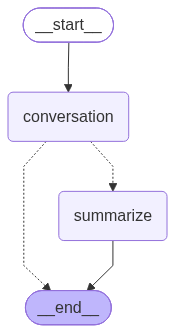

In [27]:
workflow = StateGraph(State)
workflow.add_node('conversation', conversation)
workflow.add_node('summarize', summarize)
workflow.add_edge(START, 'conversation')
workflow.add_conditional_edges('conversation', should_continue)
workflow.add_edge('summarize', END)

graph = workflow.compile(checkpointer = MemorySaver())
graph

In [28]:
config = {'configurable': {'thread_id': '1'}}

In [13]:
for chunk in graph.stream({'messages': [HumanMessage(content='I am Ayush')]}, config=config, stream_modes = 'updates'):
    print(chunk)

{'conversation': {'messages': AIMessage(content='Hi Ayush! 👋 Nice to meet you!\n\nHow can I help you today? Feel free to ask me anything or just start a conversation. 😊', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '16165cad-de1f-421c-a68e-6fd440b50703', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 12 Aug 2026 10:53:50 GMT', 'content-type': 'application/json', 'content-length': '438', 'connection': 'keep-alive', 'x-amzn-requestid': '16165cad-de1f-421c-a68e-6fd440b50703'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [1366]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019ff59b-62c9-7ee3-8434-59cf51971d38-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 40, 'total_tokens': 52, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})}}


In [29]:
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Ayush")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Hi Ayush! Nice to meet you! 😊

How are you doing? Is there something I can help you with today?


Let's look at `stream_mode="updates"`.

Because we stream with `updates`, we only see updates to the state after node in the graph is run.

Each `chunk` is a dict with `node_name` as the key and the updated state as the value.


Now, we can see `stream_mode="values"`.

This is the `full state` of the graph after the `conversation` node is called.

In [46]:
config = {"configurable": {"thread_id": "2"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Ayush")]}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content="hi! I'm Ayush", additional_kwargs={}, response_metadata={}, id='6d01fdbe-bac9-4736-8f22-f2ae8bcdd9a9')]}
{'messages': [HumanMessage(content="hi! I'm Ayush", additional_kwargs={}, response_metadata={}, id='6d01fdbe-bac9-4736-8f22-f2ae8bcdd9a9'), AIMessage(content='Hi Ayush! Nice to meet you! 😊\n\nHow are you doing? Is there something I can help you with today?', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '87ae6b63-ed38-4c80-9415-eaa71fe33c97', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 12 Aug 2026 11:08:03 GMT', 'content-type': 'application/json', 'content-length': '413', 'connection': 'keep-alive', 'x-amzn-requestid': '87ae6b63-ed38-4c80-9415-eaa71fe33c97'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [1318]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019ff5a8-64e3-7223-8e15-2cc6e6502675-0', tool_calls=[], invalid_tool_calls=

In [49]:
config = {"configurable": {"thread_id": "3"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Ayush")

for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in chunk['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Ayush
================================== Ai Message ==================================

Hi Ayush! Nice to meet you! 😊

How are you doing? Is there something I can help you with today?
================================ Human Message =================================

hi! I'm Ayush
================================== Ai Message ==================================

Hi again, Ayush! 😄

It looks like you sent that twice - no worries! Is there anything I can help you with today?
================================ Human Message =================================

hi! I'm Ayush
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Ayush
================================== Ai Message ==================================

Hi Ayush! Nice to meet you! 😊

How are you doing? Is there something I can help you w

#### Streaming tokens

We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this [using the `.astream_events` method](https://docs.langchain.com/oss/python/langchain/models#advanced-streaming-topics:streaming-events), which streams back events as they happen inside nodes!

Each event is a dict with a few keys:
 
* `event`: This is the type of event that is being emitted. 
* `name`: This is the name of event.
* `data`: This is the data associated with the event.
* `metadata`: Contains`langgraph_node`, the node emitting the event.

Let's have a look.

In [50]:
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the langgraph")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. EventType: {event['event']}. Name: {event['name']}. Data: {event['data']}")

Node: . EventType: on_chain_start. Name: LangGraph. Data: {'input': {'messages': [HumanMessage(content='Tell me about the langgraph', additional_kwargs={}, response_metadata={})]}}
Node: conversation. EventType: on_chain_start. Name: conversation. Data: {'input': {'messages': [HumanMessage(content='Tell me about the langgraph', additional_kwargs={}, response_metadata={}, id='b8b5c5d2-94eb-4fdc-b5a8-2903a481f910')]}}
Node: conversation. EventType: on_chat_model_start. Name: ChatBedrockConverse. Data: {'input': {'messages': [[HumanMessage(content='Tell me about the langgraph', additional_kwargs={}, response_metadata={}, id='b8b5c5d2-94eb-4fdc-b5a8-2903a481f910')]]}}
Node: conversation. EventType: on_chat_model_stream. Name: ChatBedrockConverse. Data: {'chunk': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'model_provider': 'bedrock_converse'}, id='lc_run--019ff5ab-d7a3-7581-8ac3-322d0ad8068a', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
Node: convers

In [51]:
node_to_stream = 'conversation'

config = {"configurable": {"thread_id": "5"}}

input_message = HumanMessage(content="Tell me about langgraph")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'model_provider': 'bedrock_converse'}, id='lc_run--019ff5ac-8359-7270-9142-888e89ea6ee0', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=[{'type': 'text', 'text': '#', 'index': 0}], additional_kwargs={}, response_metadata={'model_provider': 'bedrock_converse'}, id='lc_run--019ff5ac-8359-7270-9142-888e89ea6ee0', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=[{'type': 'text', 'text': ' L', 'index': 0}], additional_kwargs={}, response_metadata={'model_provider': 'bedrock_converse'}, id='lc_run--019ff5ac-8359-7270-9142-888e89ea6ee0', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=[{'type': 'text', 'text': 'angGraph', 'index': 0}], additional_kwargs={}, response_metadata={'model_provider': 'bedrock_converse'}, id='lc_run--019ff5ac-8359-7270-9142-888e89ea6ee0', tool_calls=[], in

In [52]:
input_message = HumanMessage(content="Tell me about Agentic AI")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|", flush=True)

[]|[{'type': 'text', 'text': '# Agentic AI', 'index': 0}]|[{'type': 'text', 'text': '\n\n## What is Agentic AI', 'index': 0}]|[{'type': 'text', 'text': '?\n\n**', 'index': 0}]|[{'type': 'text', 'text': 'Agentic AI** refers', 'index': 0}]|[{'type': 'text', 'text': ' to AI systems that can', 'index': 0}]|[{'type': 'text', 'text': ' **', 'index': 0}]|[{'type': 'text', 'text': 'autonom', 'index': 0}]|[{'type': 'text', 'text': 'ously plan', 'index': 0}]|[{'type': 'text', 'text': ', decide', 'index': 0}]|[{'type': 'text', 'text': ', and take', 'index': 0}]|[{'type': 'text', 'text': ' actions** to', 'index': 0}]|[{'type': 'text', 'text': ' achieve goals —', 'index': 0}]|[{'type': 'text', 'text': ' going', 'index': 0}]|[{'type': 'text', 'text': ' beyond simple question', 'index': 0}]|[{'type': 'text', 'text': '-answering to', 'index': 0}]|[{'type': 'text', 'text': ' actually', 'index': 0}]|[{'type': 'text', 'text': ' *', 'index': 0}]|[{'type': 'text', 'text': 'doing', 'index': 0}]|[{'type': 't

We can also use the LangGraph API, for more